# UnCLIP: The Model Behind OpenAI’s DALL·E 2

In this tutorial, we will walk through how to build and train an **UnCLIP model** using the [TorchDiff](https://loqmansamani.github.io/torchdiff/) diffusion library. TorchDiff is a flexible diffusion framework built on top of [PyTorch](https://pytorch.org/), and this tutorial focuses on the **UnCLIP architecture (DALL·E 2)**, as introduced in the paper:  
[Hierarchical Text-Conditional Image Generation with CLIP Latents](https://arxiv.org/abs/2204.06125).

⚠️ **Note**: This notebook does not train a model end-to-end in real time. Instead, it demonstrates the main components of the UnCLIP pipeline and shows how to train each sub-model using the TorchDiff API.

<br>
<div align="center">
  <img src="unclip_.png" alt="UnCLIP overview" width="1000"/>
  <br>
  <em>An overview of the UnCLIP pipeline, adapted from the original paper.</em>
  <br><br>
</div>

---

## Table of Contents

- [Data Preparation](#data-preparation)  
- [Train the Diffusion Prior Model](#train-diffusion-prior)  
- [Train the Decoder Model](#train-decoder)  
- [Train the First Upsampler: 64×64 → 256×256](#train-first-upsampler)  
- [Train the Second Upsampler: 256×256 → 1024×1024](#train-second-upsampler)  
- [Sampling Pipeline](#sampling-pipeline)  



In [1]:
# Import core Python and visualization libraries
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# PyTorch essentials
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, Subset

# ----------------------------
# TorchDiff: UnCLIP Components
# ----------------------------

# Diffusion scheduling and processes
from unclip import VarianceSchedulerUnCLIP, ForwardUnCLIP, ReverseUnCLIP

# CLIP models for encoding images and text into latent space
from unclip import CLIPEncoder, CLIPContextProjection, CLIPEmbeddingProjection

# Prior model (transformer-based) and training utilities
from unclip import UnCLIPTransformerPrior, TrainUnCLIPPrior

# Decoder model and training utilities
from unclip import UnClipDecoder, TrainUnClipDecoder

# Upsampler models (progressive super-resolution) and their trainers
from unclip import UpsamplerUnCLIP, TrainUpsamplerUnCLIP

# Full UnCLIP sampling pipeline
from unclip import SampleUnCLIP

# ----------------------------
# Utility classes
# ----------------------------
from utils import NoisePredictor, TextEncoder, Metrics

## Data Preparation

For this tutorial, we will use the [CIFAR-10](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html) dataset, provided by [Torchvision](https://pytorch.org/vision/stable/).  
CIFAR-10 contains **60,000 RGB images** across 10 classes, each with a resolution of **32×32**.  

To make this dataset more suitable for **text-to-image training experiments**, we will assign a **mock descriptive caption** to each image. These captions are generated from simple templates and are only used for **educational purposes** in this tutorial.  

The dataset will then be resized and normalized for compatibility with the **CLIP encoder**.


In [2]:
# ----------------------------
# CIFAR-10 with Mock Captions
# ----------------------------
class CIFAR10WithCaptions(Dataset):
    def __init__(self, cifar_dataset):
        self.dataset = cifar_dataset
        self.class_names = [
            'airplane', 'automobile', 'bird', 'cat', 'deer',
            'dog', 'frog', 'horse', 'ship', 'truck'
        ]
        # Templates for generating simple descriptive captions
        self.caption_templates = [
            "A photo of a {}",
            "An image of a {}",
            "A picture of a {}",
            "This is a {}",
        ]

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        image, label = self.dataset[index]
        class_name = self.class_names[label]
        # Rotate between templates for variety
        template = self.caption_templates[index % len(self.caption_templates)]
        caption = template.format(class_name)
        return image, caption


# ----------------------------
# Image Transformations
# ----------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize for CLIP encoder input
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # CLIP normalization
        std=[0.229, 0.224, 0.225]
    )
])

# ----------------------------
# Load CIFAR-10 Dataset
# ----------------------------
cifar10_train = datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)
cifar10_test = datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

# Wrap datasets with captions
train_dataset = CIFAR10WithCaptions(cifar10_train)
test_dataset = CIFAR10WithCaptions(cifar10_test)

#### Visualizing Training Images

Before training, let’s visualize a few examples from our **training dataset** along with their generated captions.  
This helps us verify that both the **image preprocessing** and **caption generation** are working correctly.

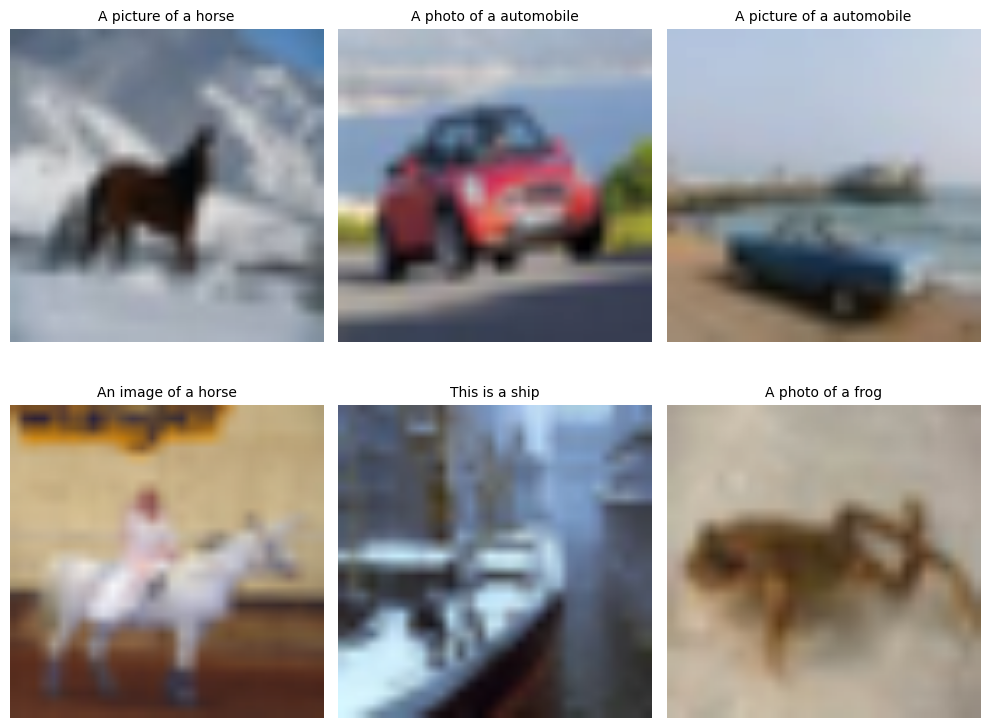

In [35]:
# ----------------------------
# Helper: Denormalize Image
# ----------------------------
def denormalize_image(tensor_image):
    """Convert a normalized tensor image back to [0,1] range for visualization."""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # Convert from CHW (PyTorch) to HWC (NumPy)
    image = tensor_image.numpy().transpose(1, 2, 0)

    # Undo normalization
    image = std * image + mean
    return np.clip(image, 0, 1)


# ----------------------------
# Visualization Function
# ----------------------------
def visualize_dataset_samples(dataset, num_samples=6, ncols=3):
    """Visualize a grid of dataset samples with their generated captions."""
    nrows = int(np.ceil(num_samples / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 4 * nrows))
    axes = axes.ravel()  # Flatten axis array for easy iteration

    # Randomly select indices from the dataset
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    for i, idx in enumerate(indices):
        image, caption = dataset[idx]
        image = denormalize_image(image)

        axes[i].imshow(image)
        axes[i].set_title(caption, fontsize=10)
        axes[i].axis('off')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


# ----------------------------
# Show a few training samples
# ----------------------------
visualize_dataset_samples(train_dataset, num_samples=6, ncols=3)

---
### Using a Subset of CIFAR-10

For demonstration purposes, we will use only a **small subset** of the CIFAR-10 dataset for both training and validation.  
This allows us to quickly illustrate the workflow without requiring significant computational resources.

In [3]:
# ----------------------------
# Select Small Subsets of Data
# ----------------------------

# Randomly select 4 samples for training and 1 for validation
train_subset_indices = torch.randperm(len(train_dataset))[:4]
test_subset_indices = torch.randperm(len(test_dataset))[:2]

# Wrap the subsets
train_subset = Subset(train_dataset, train_subset_indices)
test_subset = Subset(test_dataset, test_subset_indices)

# ----------------------------
# Create DataLoaders
# ----------------------------
train_loader = DataLoader(
    train_subset, batch_size=2, shuffle=True, pin_memory=True
)
val_loader = DataLoader(
    test_subset, batch_size=1, shuffle=False, pin_memory=True
)

### Considerations for Dataset and Scalability

The subset used here is **far too small** to properly train a diffusion model.  
Our objective is to **demonstrate the TorchDiff API workflow** rather than achieve high-quality results.  

For meaningful training:  
- Increase the dataset size substantially.  
- Use higher-resolution RGB images for better fidelity.  
- Consider domain-specific datasets if your application requires it.  

### Training a Diffusion Prior Model

To generate **image embeddings from text prompts**, UnCLIP relies on a **prior model**.  
The original paper tested two variants:  

- **Autoregressive Prior (AR)**  
- **Diffusion Prior**  

The authors found that the **Diffusion Prior** was **more efficient** and produced **better results** than the AR variant.  
Therefore, TorchDiff implements the **Diffusion Prior** as the default prior model in the UnCLIP pipeline.

---

#### Prior Model Pipeline

1. **Encode Texts and Images with CLIP**  
   - Text captions and images are embedded using **pre-trained CLIP models** (from Hugging Face’s `transformers` library).  
   - This produces text embeddings (`z_t`) and image embeddings (`z_i`).  

2. **Optional Dimensionality Reduction**  
   - Image embeddings (`z_i`) may be passed through a **projection network** to reduce dimensionality.  
   - While the original paper used **PCA**, TorchDiff uses a **trainable projection layer**, making the reduction learnable and more flexible.  

3. **Diffusion Prior Training**  
   - The diffusion prior is trained on pairs of (`z_t`, `z_i_reduced`).  
   - Its **noise predictor** is a **transformer architecture**, but unlike conventional diffusion models (which predict noise),  
     the UnCLIP prior is trained to **predict clean image embeddings** from **noisy image embeddings + text embeddings**.  

### Preparing Modules for the Prior Trainer

Before training the **Diffusion Prior**, we need to set up its core components:

1. **Variance Scheduler** – defines the noise schedule for forward and reverse diffusion.  
   - We use a cosine schedule, consistent with the UnCLIP paper.  
   - The `tau_num_steps` parameter controls the efficiency of sampling, inspired by **DDIM**.  

2. **Forward & Reverse Diffusion** – implement the diffusion process (noising and denoising).  

3. **CLIP Encoder** – pre-trained model that provides text and image embeddings.  

4. **Projection Networks** – learnable feed-forward layers that reduce the dimensionality of CLIP embeddings.  
   - TorchDiff replaces PCA (used in the paper) with **trainable projections**.  

5. **Transformer Prior** – the main model, trained to denoise image embeddings conditioned on text embeddings.  

6. **Optimizer & Loss Function** – standard components for training.  
   - Optimizer: `AdamW`  
   - Loss: `MSELoss` (predicting clean embeddings from noisy embeddings).  

In [4]:
# ----------------------------
# Variance Scheduler
# ----------------------------
prior_scheduler = VarianceSchedulerUnCLIP(
    num_steps=1000,
    tau_num_steps=1000,       # Sampling steps (DDIM-inspired, set equal to training steps in UnCLIP paper)
    beta_start=1e-4,
    beta_end=0.02,
    trainable_beta=False,     # Variance not learnable
    beta_method="cosine"
)

# ----------------------------
# Forward and Reverse Diffusion Processes
# ----------------------------
prior_forward_diffusion = ForwardUnCLIP(prior_scheduler)
prior_reverse_diffusion = ReverseUnCLIP(prior_scheduler)

# ----------------------------
# CLIP Encoder (text and image embeddings)
# ----------------------------
clip_encoder = CLIPEncoder(model_name="openai/clip-vit-base-patch32")

# ----------------------------
# Projection Networks (Trainable replacement for PCA)
# ----------------------------
text_projection = CLIPEmbeddingProjection(
    clip_embedding_dim=512,
    transformer_embedding_dim=320,
    hidden_dim=480,
    num_layers=2,
    dropout_rate=0.1,
    use_layer_norm=True
)

image_projection = CLIPEmbeddingProjection(
    clip_embedding_dim=512,
    transformer_embedding_dim=320,
    hidden_dim=480,
    num_layers=2,
    dropout_rate=0.1,
    use_layer_norm=True
)

# ----------------------------
# Transformer Prior Model
# ----------------------------
prior_model = UnCLIPTransformerPrior(
    forward_diffusion=prior_forward_diffusion,
    reverse_diffusion=prior_reverse_diffusion,   # Used during training
    clip_text_projection=text_projection,        # Trainable replacement for PCA
    clip_image_projection=image_projection,      # Trainable replacement for PCA
    transformer_embedding_dim=320,
    num_layers=12,
    num_attention_heads=8,
    feedforward_dim=512,
    max_sequence_length=2,
    dropout_rate=0.3
)

# ----------------------------
# Optimizer and Loss Function
# ----------------------------
optimizer = torch.optim.AdamW(
    [p for p in prior_model.parameters() if p.requires_grad], 
    lr=1e-5
)
criterion = nn.MSELoss()

In [39]:
# ----------------------------
# Initialize the Prior Model Trainer
# ----------------------------
prior_trainer = TrainUnCLIPPrior(
    prior_model=prior_model,
    clip_model=clip_encoder,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    objective=criterion,
    
    # Training configuration
    max_epochs=10,
    device="cuda",
    grad_accumulation_steps=2,
    warmup_epochs=2,
    patience=10,              # Early stopping patience
    val_frequency=3,          # Run validation every N epochs
    log_frequency=1,          # Log training progress every epoch
    
    # Checkpointing and storage
    store_path="prior_model",
    
    # Advanced settings
    use_ddp=False,            # Enable if using multiple GPUs
    use_compilation=False,    # Disable model compilation (not required here)
    
    # Embedding handling
    embedding_output_range=(-1.0, 1.0),
    reduce_clip_embedding_dim=True,
    transformer_embedding_dim=320,
    normalize_clip_embeddings=True
)

Before starting training, let’s inspect the **total number of trainable parameters** in the Prior model.  
This helps us understand the model’s scale and computational requirements.

In [40]:
# Count total parameters in the trainer (including the prior model)
num_params = sum(param.numel() for param in prior_trainer.parameters())
print(f"Number of trainable parameters in the Prior model: {num_params:,}")

Number of trainable parameters in the Prior model: 162,079,041


---

Now we are ready to begin training the **Diffusion Prior** using our small dataset subset.  
The training loop is handled internally by the `TrainUnCLIPPrior` class, which manages:  

- Forward and backward passes  
- Gradient accumulation  
- Validation and checkpointing  
- Early stopping based on validation loss  

In [41]:
# ----------------------------
# Start Training
# ----------------------------
train_losses, best_val_loss = prior_trainer()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:01<00:00,  2.72it/s]


Epoch 1/10 | LR: 1.00e-05 | Train Loss: 0.2527


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:01<00:00,  3.34it/s]


Epoch 2/10 | LR: 1.00e-05 | Train Loss: 0.2407


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:01<00:00,  3.32it/s]


...

Epoch 8/10 | LR: 1.00e-05 | Train Loss: 0.1555


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:01<00:00,  3.33it/s]


Epoch 9/10 | LR: 1.00e-05 | Train Loss: 0.1469 | Val Loss: 0.1536


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:01<00:00,  3.55it/s]

Epoch 10/10 | LR: 1.00e-05 | Train Loss: 0.1396


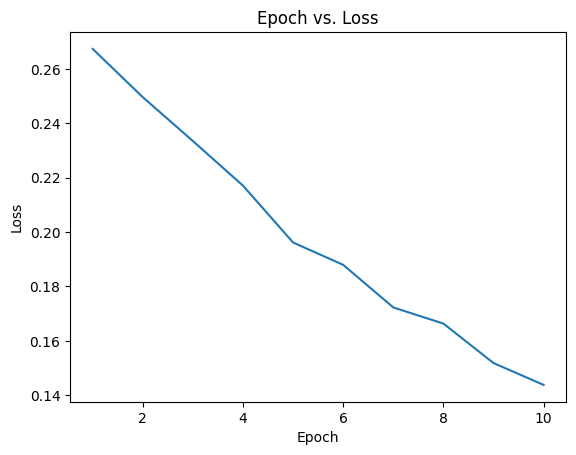

In [9]:
plt.plot([i for i in range(1, 11)], train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs. Loss")
plt.show()

---
### Training the Decoder Model

The **Decoder Model** is responsible for converting **CLIP image embeddings** into actual images using a diffusion process.  
It follows a conditional generation scheme, where both **text prompts** and **image embeddings** guide the denoising process.

#### Decoder Forward Pass Workflow:
1. **Project CLIP Image Embeddings**  
   - Image embeddings are mapped into 4 additional tokens (`C`) using a projection layer.  

2. **Encode Text Prompts**  
   - Texts are processed with a **GLIDE-like transformer-based encoder**, producing embeddings (`E`).  

3. **Build Context**  
   - Concatenate `E` and `C` → combined **context embeddings**.  

4. **Add Noise to Images**  
   - Starting from clean images, Gaussian noise and timesteps are applied to generate **noisy images**.  

5. **Predict Noise with U-Net**  
   - A U-Net-like noise predictor (with attention layers) predicts noise, conditioned on:
     - Noisy images  
     - Timestep embeddings  
     - Context embeddings  
     - Image embeddings  

This diffusion training enables the decoder to progressively denoise images conditioned on both **text** and **CLIP embeddings**.

In [5]:
# ----------------------------
# Noise Predictor (U-Net with attention)
# ----------------------------
noise_predictor = NoisePredictor(
    in_channels=3,
    down_channels=[16, 32],
    mid_channels=[32, 32],
    up_channels=[32, 16],
    down_sampling=[True, True],
    time_embed_dim=512,
    y_embed_dim=512,
    num_down_blocks=1,
    num_mid_blocks=1,
    num_up_blocks=1,
    down_sampling_factor=2
)

# ----------------------------
# Variance Scheduler for Decoder
# ----------------------------
decoder_scheduler = VarianceSchedulerUnCLIP(
    num_steps=500,
    tau_num_steps=100,    # Like DDIM: fewer steps for efficiency
    beta_start=1e-4,
    beta_end=0.02,
    trainable_beta=False,
    beta_method="cosine"
)

# ----------------------------
# Forward and Reverse Diffusion
# ----------------------------
decoder_forward_diffusion = ForwardUnCLIP(decoder_scheduler)
decoder_reverse_diffusion = ReverseUnCLIP(decoder_scheduler)

# ----------------------------
# GLIDE-like Text Encoder
# ----------------------------
glide_text_encoder = TextEncoder(
    use_pretrained_model=True,
    model_name="bert-base-uncased",
    vocabulary_size=30522,
    num_layers=1,
    input_dimension=512,
    output_dimension=512,
    num_heads=1,
    context_length=77
)

# ----------------------------
# Decoder Model
# ----------------------------
decoder_model = UnClipDecoder(
    clip_embedding_dim=512,
    noise_predictor=noise_predictor,
    forward_diffusion=decoder_forward_diffusion,
    reverse_diffusion=decoder_reverse_diffusion,
    glide_text_encoder=glide_text_encoder,
    bert_tokenizer=None,
    device=None,
    image_output_range=(-1.0, 1.0),
    normalize_clip_embeddings=True,
    classifier_free_prop=0.1,   # As specified in the paper
    drop_caption=0.5,           # As specified in the paper
    max_token_length=77
)

# ----------------------------
# Optimizer and Loss
# ----------------------------
decoder_optimizer = torch.optim.AdamW(
    [p for p in decoder_model.parameters() if p.requires_grad], 
    lr=1e-5
)

decoder_loss = nn.MSELoss()

# ----------------------------
# Evaluation Metrics
# ----------------------------
metrics = Metrics(
    device="cpu",
    fid=False,
    metrics=True,
    lpips_=True
)  # Includes FID, LPIPS, MSE, SSIM, and PSNR

### Preparing the Decoder Trainer

Next, we wrap the **Decoder Model** with its trainer.  
The `TrainUnClipDecoder` class handles the training loop, validation, checkpointing, and evaluation metrics.  

We also reuse the **CLIP projection networks** (`text_projection`, `image_projection`) from the prior model:  
- These are already trained.  
- They can optionally be fine-tuned (`finetune_clip_projections=True`).  

In [6]:
# ----------------------------
# Initialize Decoder Trainer
# ----------------------------
decoder_trainer = TrainUnClipDecoder(
    clip_embedding_dim=512,
    decoder_model=decoder_model,
    clip_model=clip_encoder,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=decoder_optimizer,
    objective=decoder_loss,
    
    # Pretrained CLIP projection layers
    clip_text_projection=text_projection,   # Fine-tuning optional
    clip_image_projection=image_projection, # Fine-tuning optional
    
    # Training configuration
    max_epochs=5,
    device="cuda",
    grad_accumulation_steps=1,
    warmup_epochs=2,
    patience=5,
    val_frequency=3,
    log_frequency=1,
    
    # Checkpointing and storage
    store_path="../torchdiff/unclip_decoder",
    
    # Advanced settings
    use_ddp=False,           # Enable if using multiple GPUs
    use_compilation=False,   # Not required here
    
    # Embedding handling
    image_output_range=(-1.0, 1.0),
    reduce_clip_embedding_dim=False,
    transformer_embedding_dim=320,
    normalize_clip_embeddings=True,
    finetune_clip_projections=False  # Disable fine-tuning by default
)

### Decoder Model Parameter Count

Before training, let’s inspect the total number of parameters in the **Decoder Model**.  
We will report both:  

- **Total Parameters** – includes all weights (trainable + frozen).  
- **Trainable Parameters** – only those updated during training.  

This helps assess the model’s complexity and the computational effort required.


In [7]:
# ----------------------------
# Count Parameters in Decoder Model
# ----------------------------
total_params = sum(param.numel() for param in decoder_trainer.parameters())
trainable_params = sum(param.numel() for param in decoder_trainer.parameters() if param.requires_grad)

print(f"Total parameters in the Decoder model: {total_params:,}")
print(f"Trainable parameters in the Decoder model: {trainable_params:,}")

Total parameters in the Decoder model: 263,198,356
Trainable parameters in the Decoder model: 153,716,116


In [8]:
train_losses, best_val_loss = decoder_trainer()

  0%|                                                                                                                                                                                                | 0/2 [00:00<?, ?it/s]/home/loqman/Downloads/projs/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.06s/it]


Epoch 1/5 | LR: 1.00e-05 | Train Loss: 1.8763


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.88it/s]


Epoch 2/5 | LR: 1.00e-05 | Train Loss: 1.7151


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.87it/s]


Epoch 3/5 | LR: 1.00e-05 | Train Loss: 1.5622
 | Val Loss: 1.6139
Best model saved: unclip_decoder/unclip_decoder_best.pth


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.94it/s]


Epoch 4/5 | LR: 1.00e-05 | Train Loss: 1.6077


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.86it/s]

Epoch 5/5 | LR: 1.00e-05 | Train Loss: 1.5685


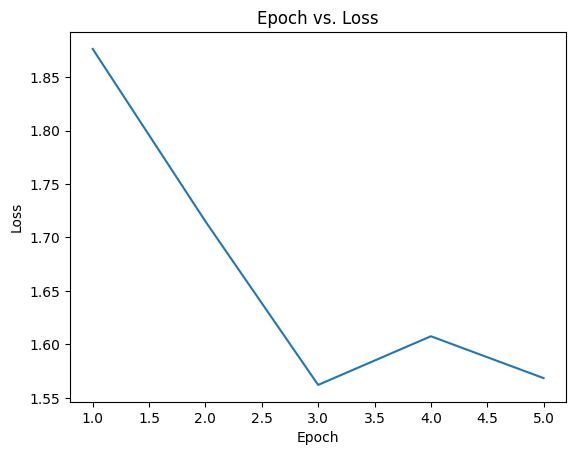

In [9]:
plt.plot([i for i in range(1, 6)], train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs. Loss")
plt.show()

The training curve appears somewhat unstable, which is expected due to the extremely small dataset size used in this example (only 4 images). 
In practice, using a larger dataset will stabilize training and improve model generalization, but hardware limitations prevent us from doing so in this demonstration.

### Training the First Upsampler (64x64 → 256x256)

The UnCLIP model uses two upsamplers to enhance the resolution and quality of generated images.  
These upsamplers are diffusion-based U-Net architectures that transform low-resolution images into high-resolution images, conditioned on noisy high-resolution images and diffusion timesteps.

To train an upsampler, we require the same dataset in two resolutions: low-resolution and high-resolution.  
Below, we define a simple synthetic dataset generator that produces pairs of low- and high-resolution images. This will serve as a placeholder; in practice, you should replace it with your actual dataset.

In [10]:
# Define a dummy dataset to simulate low- and high-resolution image pairs
# In practice, replace this with a real dataset loader
class DummyUpsampleDataset(Dataset):
    def __init__(self, num_samples=1000, low_res_size=64, high_res_size=256):
        self.num_samples = num_samples
        self.low_res_size = low_res_size
        self.high_res_size = high_res_size

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Generate synthetic low-res and high-res images normalized to [-1, 1]
        low_res_image = torch.rand(3, self.low_res_size, self.low_res_size) * 2 - 1
        high_res_image = torch.rand(3, self.high_res_size, self.high_res_size) * 2 - 1
        return low_res_image, high_res_image

In [11]:
# --- Setup for the First Upsampler ---

# Instantiate variance scheduler for diffusion process
upsampler_one_scheduler = VarianceSchedulerUnCLIP(
    num_steps=400,
    tau_num_steps=50,
    beta_start=1e-4,
    beta_end=0.02,
    trainable_beta=False,
    beta_method="cosine"
)

# Create forward and reverse diffusion processes
forward_diffusion_process = ForwardUnCLIP(upsampler_one_scheduler)
reverse_diffusion_process = ReverseUnCLIP(upsampler_one_scheduler)

# Initialize the upsampler model
upsampler_one = UpsamplerUnCLIP(
    forward_diffusion=forward_diffusion_process,
    reverse_diffusion=reverse_diffusion_process,
    in_channels=3,
    out_channels=3,
    model_channels=32,
    num_res_blocks=2,
    channel_mult=(1, 2, 4, 8),
    dropout_rate=0.1,
    time_embed_dim=32,
    low_res_size=64,   # Low-resolution input size (64x64)
    high_res_size=256  # High-resolution target size (256x256)
)

# Create DataLoaders using dummy dataset (replace with real dataset in practice)
train_dataset = DummyUpsampleDataset(num_samples=4)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=0)

val_dataset = DummyUpsampleDataset(num_samples=1)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)

# Define optimizer for training
optimizer = torch.optim.AdamW(upsampler_one.parameters(), lr=1e-5)

# Define the training objective (loss function)
loss_function = nn.MSELoss()

### Inspecting the Upsampler's Parameters

Before training, it is often useful to understand the size of the model.  
Here, we calculate both the total number of parameters and the number of trainable parameters in the first upsampler.

In [13]:
# Calculate the total and trainable parameters of the upsampler
total_params = sum(p.numel() for p in upsampler_one.parameters())
trainable_params = sum(p.numel() for p in upsampler_one.parameters() if p.requires_grad)

print(f"Total number of parameters in the upsampler: {total_params:,}")
print(f"Number of trainable parameters: {trainable_params:,}")

Total number of parameters in the upsampler: 12,808,131
Number of trainable parameters: 12,808,131


---
### Setting Up the Training Routine

Next, we configure the training routine for the first upsampler.  
We use the `TrainUpsamplerUnCLIP` trainer, which handles the forward and reverse diffusion steps, logging, validation, and checkpointing.  

Key training options include:
- `max_epochs`: maximum number of training epochs.
- `patience`: early stopping patience based on validation loss.
- `grad_accumulation_steps`: for gradient accumulation in case of small batch sizes.
- `device`: device to train on (CPU or GPU).
- `use_ddp`: set to `True` for distributed data-parallel training.
- `image_output_range` and `normalize_image_outputs`: ensure outputs are in the correct range for diffusion models.

In [14]:
# Instantiate the upsampler trainer
upsampler_trainer = TrainUpsamplerUnCLIP(
    upsampler_model=upsampler_one,
    train_loader=train_loader,
    optimizer=optimizer,
    objective=loss_function,
    val_loader=val_loader,
    max_epochs=10,
    device='cuda',
    store_path="../torchdiff/upsampler_one",
    patience=10,
    warmup_epochs=2,
    val_frequency=5,
    use_ddp=False,                # Set True if using distributed training
    grad_accumulation_steps=2,    # Gradient accumulation for small batch sizes
    log_frequency=1,              # Print logs every N iterations
    use_compilation=False,        # Set True to use torch.compile for faster execution
    image_output_range=(-1.0, 1.0),
    normalize_image_outputs=True,
    use_autocast=False
)

### Start Training the First Upsampler

Now we can start the training loop.  
The trainer will return both the training loss history and the best validation loss achieved during training.


In [15]:
# Run the training loop
training_losses, best_validation_loss = upsampler_trainer()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  2.22it/s]


Epoch 1/10 | LR: 5.00e-06 | Train Loss: 1.1138


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  3.43it/s]


Epoch 2/10 | LR: 1.00e-05 | Train Loss: 1.1073


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  3.52it/s]


...

Epoch 8/10 | LR: 1.00e-05 | Train Loss: 1.0842


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  3.36it/s]


Epoch 9/10 | LR: 1.00e-05 | Train Loss: 1.0739


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  3.54it/s]


Epoch 10/10 | LR: 1.00e-05 | Train Loss: 1.0682
 | Val Loss: 1.0552

Best model saved: upsampler_one/unclip_upsampler_best.pth


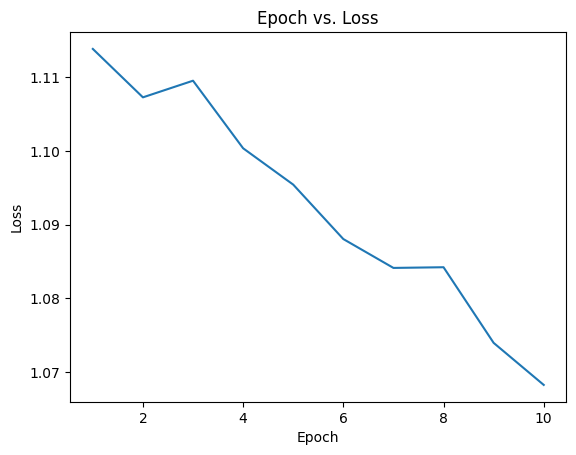

In [17]:
plt.plot([i for i in range(1, 11)], training_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs. Loss")
plt.show()

---
### Training the Second Upsampler (256x256 → 1024x1024)

The second upsampler is the final stage in the UnCLIP pipeline.  
Its output constitutes the final high-resolution images produced by the model.  

We follow a similar setup as the first upsampler, but this time the input is 256×256 images, and the output is 1024×1024 images.  

In [18]:
# --- Setup for the Second Upsampler ---

# Instantiate variance scheduler for diffusion process
upsampler_two_scheduler = VarianceSchedulerUnCLIP(
    num_steps=400,
    tau_num_steps=50,
    beta_start=1e-4,
    beta_end=0.02,
    trainable_beta=False,
    beta_method="cosine"
)

# Create forward and reverse diffusion processes
forward_diffusion_upsampler_two = ForwardUnCLIP(upsampler_two_scheduler)
reverse_diffusion_upsampler_two = ReverseUnCLIP(upsampler_two_scheduler)

# Initialize the second upsampler model
upsampler_two = UpsamplerUnCLIP(
    forward_diffusion=forward_diffusion_upsampler_two,
    reverse_diffusion=reverse_diffusion_upsampler_two,
    in_channels=3,
    out_channels=3,
    model_channels=32,
    num_res_blocks=2,
    channel_mult=(1, 2, 4, 8),
    dropout_rate=0.1,
    time_embed_dim=32,
    low_res_size=256,   # Input resolution (low-res)
    high_res_size=1024  # Output resolution (high-res)
)

# Define optimizer for the second upsampler
optimizer_upsampler_two = torch.optim.AdamW(upsampler_two.parameters(), lr=1e-5)

# Define training objective (loss function, e.g., MSE for noise prediction)
loss_function_upsampler_two = nn.MSELoss()

### Inspecting the Second Upsampler's Parameters

Similar to the first upsampler, let's check the total and trainable parameters of the second upsampler.

In [19]:
# Calculate total and trainable parameters
total_params_two = sum(p.numel() for p in upsampler_two.parameters())
trainable_params_two = sum(p.numel() for p in upsampler_two.parameters() if p.requires_grad)

print(f"Total number of parameters in the second upsampler: {total_params_two:,}")
print(f"Number of trainable parameters: {trainable_params_two:,}")

Total number of parameters in the second upsampler: 12,808,131
Number of trainable parameters: 12,808,131


---

### Setting Up the Trainer for the Second Upsampler

We use the same `TrainUpsamplerUnCLIP` trainer as before.  
The configuration is largely identical to the first upsampler, but with a dedicated storage path for checkpoints and logs.

In [21]:
# Instantiate the trainer for the second upsampler
upsampler_two_trainer = TrainUpsamplerUnCLIP(
    upsampler_model=upsampler_two,
    train_loader=train_loader,
    optimizer=optimizer_upsampler_two,
    objective=loss_function_upsampler_two,
    val_loader=val_loader,
    max_epochs=10,
    device='cuda',
    store_path="../torchdiff/upsampler_two",
    patience=10,
    warmup_epochs=2,
    val_frequency=5,
    use_ddp=False,                 # Set True for distributed training
    grad_accumulation_steps=2,     # Gradient accumulation for small batch sizes
    log_frequency=1,               # Logging frequency in iterations
    use_compilation=False,         # Set True to enable torch.compile
    image_output_range=(-1.0, 1.0),
    normalize_image_outputs=True,
    use_autocast=False
)

### Start Training the Second Upsampler

Run the training loop. The trainer will return the training loss history and the best validation loss achieved during training.


In [22]:
# Run the training loop for the second upsampler
training_losses_two, best_validation_loss_two = upsampler_two_trainer()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  3.03it/s]


Epoch 1/10 | LR: 5.00e-06 | Train Loss: 1.1558


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  3.38it/s]


Epoch 2/10 | LR: 1.00e-05 | Train Loss: 1.1574


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  3.45it/s]


...

Epoch 8/10 | LR: 1.00e-05 | Train Loss: 1.1206


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  3.50it/s]


Epoch 9/10 | LR: 1.00e-05 | Train Loss: 1.1124


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  3.53it/s]


Epoch 10/10 | LR: 1.00e-05 | Train Loss: 1.1125
 | Val Loss: 1.0945

Best model saved: upsampler_two/unclip_upsampler_best.pth


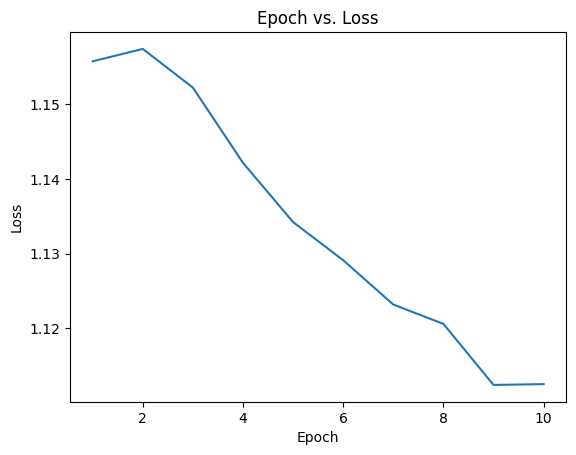

In [24]:
plt.plot([i for i in range(1, 11)], training_losses_two)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs. Loss")
plt.show()

### Sampling pipeline

now that we train all necessary components of the unclip model we will use them to generate new data (images). the sampler process consists of the folowing steps:

#### **1. Prior Model (Text → Image Embeddings)**
- Encode input **text prompt** with **CLIP** → `text_embeddings`.  
- Initialize random noise in embedding space → `embedding_noise`.  
- Optionally apply **dimensionality reduction** (`projection`).  
- **Diffusion loop** (reverse process):
  1. Predict embeddings from noisy embeddings + text.  
  2. Apply **classifier-free guidance (CFG)** to steer predictions.  
  3. Update embeddings with reverse diffusion.  
- Convert embeddings back to original dimension → `final_image_embeddings`.  

---

#### **2. Decoder Model (Embeddings → 64×64 Image)**
- Initialize random noise image (64×64).  
- Project image embeddings into decoder’s embedding space.  
- Encode text with **decoder’s text encoder (GLIDE)**.  
- Concatenate projected embeddings + text embeddings → `context`.  
- **Diffusion loop**:
  1. Predict noise from current image + context.  
  2. Apply CFG to improve quality.  
  3. Update images with reverse diffusion.  
- Output low-res image → **`generated_64x64`**.  

---

#### **3. First Upsampler (64×64 → 256×256)**
- Initialize random noise image (256×256).  
- **Diffusion loop** (conditioned on 64×64 image):
  1. Predict noise for upsampling.  
  2. Update image with reverse diffusion.  
- Output mid-res image → **`images_256`**.  

---

#### **4. Second Upsampler (Optional, 256×256 → 1024×1024)**
- Initialize random noise image (1024×1024).  
- **Diffusion loop** (conditioned on 256×256 image):
  1. Predict noise for upsampling.  
  2. Update image with reverse diffusion.  
- Output high-res image → **`images_1024`**.  

---

#### **5. Post-Processing**
- Normalize final images to range `[0,1]` (if requested).  
- Save generated images (both **256×256** and **1024×1024**, if available).  
- Return the final set of images.  

In [26]:
# Instantiate the UnCLIP sampler
unclip_sampler = SampleUnCLIP(
    prior_model=prior_model,
    decoder_model=decoder_model,
    clip_model=clip_encoder,
    low_res_upsampler=upsampler_one,
    high_res_upsampler=upsampler_two,
    device=None,
    clip_embedding_dim=512,
    prior_guidance_scale=4.0,
    decoder_guidance_scale=8.0,
    batch_size=1,
    normalize_clip_embeddings=True,
    prior_dim_reduction=True,
    initial_image_size=(3, 64, 64),
    use_high_res_upsampler=True,
    image_output_range=(-1.0, 1.0)
)

In [27]:
# Check total number of parameters in the sampler
total_sampler_params = sum(p.numel() for p in unclip_sampler.parameters())
print(f"Total number of parameters in the sampler: {total_sampler_params:,}")

Total number of parameters in the sampler: 299,616,346


In [28]:
# Generate images from text prompts
generated_images = unclip_sampler(
    prompts=["this is a test prompt"],
    normalize_output=True,
    save_images=True,
    save_path="../torchdiff/unclip_generated"
)

### Visualizing Generated Images

We can now visualize the output of the sampling pipeline at different resolutions.

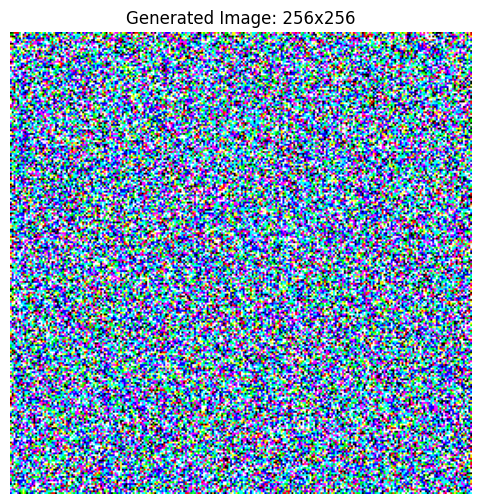

In [29]:
# --- Low-Resolution Image (256x256) ---
folder_path = "../torchdiff/unclip_generated/images_256"
image_path = os.path.join(folder_path, "image_1.png")

plt.figure(figsize=(6, 6))
img = plt.imread(image_path)
plt.imshow(img)
plt.title("Generated Image: 256x256")
plt.axis('off')
plt.show()

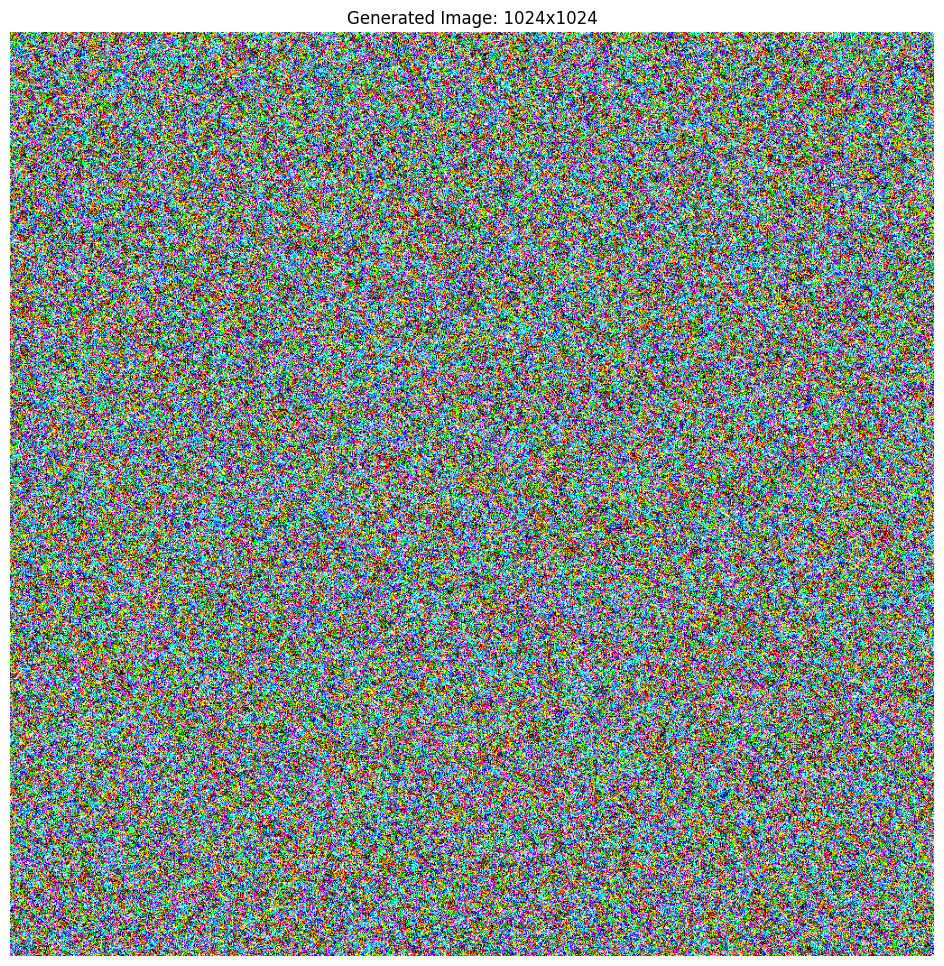

In [30]:
# --- High-Resolution Image (1024x1024) ---
folder_path = "../torchdiff/unclip_generated/images_1024"
image_path = os.path.join(folder_path, "image_1.png")

plt.figure(figsize=(12, 12))
img = plt.imread(image_path)
plt.imshow(img)
plt.title("Generated Image: 1024x1024")
plt.axis('off')
plt.show()

### Evaluating the Generated Images

Since this tutorial uses minimal training and synthetic datasets, the generated images are not expected to be high-quality.  
The goal here is to demonstrate the training and sampling workflow using the TorchDiff library.

---

## Useful Resources

- [TorchDiff Webpage](https://loqmansamani.github.io/torchdiff/): Official webpage for TorchDiff.  
- [TorchDiff GitHub Repository](https://github.com/loqmansamani/torchdiff): Source code and documentation.  
- [TorchDiff API Documentation](https://torchdiff.readthedocs.io/en/latest/index.html): Full API reference for TorchDiff.